In [1]:
# Data manipulation
import pandas as pd
import numpy as np


# Data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm

# warning management library
import warnings

# Text Mining
import nltk
nltk.download('punkt')
from wordcloud import WordCloud
from collections import Counter
nltk.download('stopwords')
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('punkt_tab')

# Machine learning
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer

# Similarity metrics
from sklearn.metrics.pairwise import cosine_similarity as cossim

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\smazo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
warnings.filterwarnings('ignore')
sns.set()
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

### 1. Loading of file movies_info.csv and selecting relevant columns

In [ ]:
titles = pd.read_csv("./Raw_Data/movies_info.csv", nrows = 15000)
#https://developer.imdb.com/non-commercial-datasets/

In [7]:
titles.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   tconst         5000 non-null   str  
 1   primaryTitle   5000 non-null   str  
 2   genres         5000 non-null   str  
 3   imdb_id        5000 non-null   str  
 4   plot_synopsis  5000 non-null   str  
 5   tags           5000 non-null   str  
dtypes: str(6)
memory usage: 234.5 KB


In [8]:
titles = titles[["primaryTitle", "genres", "plot_synopsis", "tags"]]
titles.head()

,primaryTitle,genres,plot_synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


In [9]:
titles.rename(columns={"primaryTitle": "title", "plot_synopsis": "synopsis"}, inplace=True)
titles.head()


,title,genres,synopsis,tags
0,The House of the Devil,Horror Short,The film opens with a large bat flying into a ...,paranormal gothic
1,Beauty and the Beast,Family Fantasy Romance,A widower merchant lives in a mansion with his...,fantasy
2,Cinderella,Drama Family Fantasy,"A prologue in front of the curtain, suppressed...",fantasy
3,A Trip to the Moon,Adventure Comedy Fantasy,"At a meeting of the Astronomic Club, its presi...",psychedelic satire
4,The Land Beyond the Sunset,Drama Fantasy Short,Joe is an impoverished New York newsboy who li...,fantasy storytelling


In [10]:
titles.drop_duplicates(subset="title",inplace=True)
titles.shape

(4809, 4)

### 2. Starting Natural Language Processing

#### 2.1 Lemmatization and Tokenization functions

In [11]:
# list of french stopwords : https://www.ranks.nl/stopwords/french
french_stopwords = ["alors","au","aucun","aussi","autre","avant","avec","avoir","bon","car","ce","cela","ces","ceux","chaque","ci",
                    "comme","comment","dans","des","du",
"dedans","dehors","depuis","devrait","doit","donc","début", "de","elle","elles","en","encore","essai","est","et","eu","fait","faites",
"fois","font","hors","ici","il","ils","je","juste",
"la","le","les","leur","là","ma","maintenant","mais","mes","mien","moins","mon","mot","même","ni","notre","nous","ou","où","par",
"parce","pas","peut","peu","plupart","pour","pourquoi",
"quand","que","quel","quelle","quelles","quels","qui","sa","sans","ses","seulement","si","sien","son","sont","sous","soyez","sur",
"ta","tandis","tellement","tels","tes","ton","tous",
"tout","trop","très","tu","voient","vont","votre","vous","vu","ça","étaient","état","étions","été","être", "un"]

In [12]:
# creating a list of stopwords for a specific text : with text most common words, and with french end english typical stopwords list
def stopwords_list(text,sw_nb):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[w for w in words_list if w.isalpha()]
    
    # wordcount and stopwords
    word_counts = Counter(words_list)
    stopwords_list=[count[0] for count in word_counts.most_common(sw_nb)]
    
    sw = set()
    sw.update(stopwords_list)
    sw.update(tuple(nltk.corpus.stopwords.words('english')))
    sw=list(sw)
    # adding french stopwords
    for fsw in french_stopwords:
        sw.append(fsw)
    return sw

In [13]:
# Text lemmatization and tokenization
def tokenize_text(text):
    # Lemmatization
    text=text.lower()
    lemmatizer = WordNetLemmatizer()
    text=lemmatizer.lemmatize(text)
    
    # Tokenization
    words_list=nltk.word_tokenize(text)
    words_list= [word for word in words_list if word.isalnum()]
    
    # Suppress digits
    words_list=[lemmatizer.lemmatize(w) for w in words_list if w.isalpha()]
    return words_list

In [14]:
# definition of a wordcloud function to have a small visualisation
def word_cloud(words_list):
    wordcloud=WordCloud()
    sentence=' '.join(words_list)
    wordcloud.generate(sentence)
    # create a figure
    fig, ax = plt.subplots(1,1, figsize = (9,6))
    # add interpolation = bilinear to smooth things out
    plt.imshow(wordcloud, interpolation='bilinear')
    # and remove the axis
    plt.axis("off")

#### 2.2 Text pre-processing

In [15]:
text = (titles["title"] + " " + titles["synopsis"] + " ").sum()

In [16]:
text[:100]

'The House of the Devil The film opens with a large bat flying into a medieval castle. The bat circle'

In [17]:
sw=stopwords_list(text,10)

In [18]:
sw[:20]

['doesn',
 'those',
 'did',
 'shan',
 'me',
 'now',
 'my',
 'yourselves',
 'then',
 'the',
 "shan't",
 "shouldn't",
 'does',
 'didn',
 'too',
 'from',
 "weren't",
 're',
 'hasn',
 'couldn']

In [19]:
text = (titles.loc[:,"title"] + " " +titles.loc[:,"synopsis"] + " " + titles.loc[:,"genres"] + " " + titles.loc[:,"tags"] + " ").sum()
words_list = tokenize_text(text)

In [20]:
words_list_wo_sw=[w for w in words_list if w not in sw]

In [21]:
words_list_wo_sw[:20]

['house',
 'devil',
 'film',
 'open',
 'large',
 'bat',
 'flying',
 'medieval',
 'castle',
 'bat',
 'circle',
 'room',
 'suddenly',
 'changing',
 'mephistopheles',
 'incarnation',
 'devil',
 'mephistopheles',
 'produce',
 'cauldron']

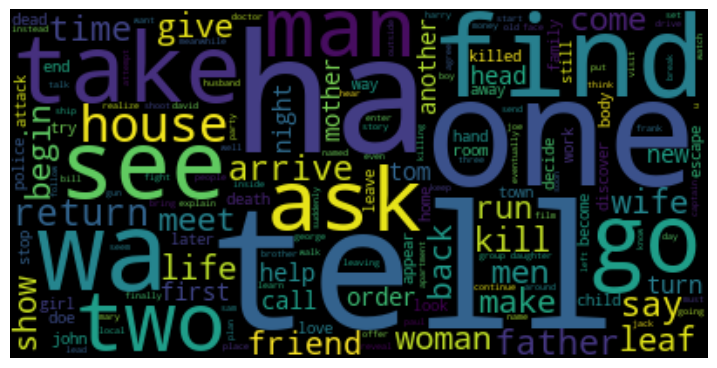

In [22]:
word_cloud(words_list_wo_sw)

#### 2.3 TF-IDF

In [23]:
tfidf = TfidfVectorizer(tokenizer=tokenize_text,stop_words=sw)

In [24]:
words_tfidf = tfidf.fit_transform((titles.iloc[:,0] + " " + titles.iloc[:,1] + " "+ titles.iloc[:,2] + " " + titles.iloc[:,3] + " "))

In [25]:
words_tfidf.shape

(4809, 61563)

### 3. Recommandations using cosine similarity

#### 3.1 recommendation function

In [26]:
cossim_matrix = cossim(words_tfidf,words_tfidf)

In [27]:
cossim_matrix.shape

(4809, 4809)

<Axes: >

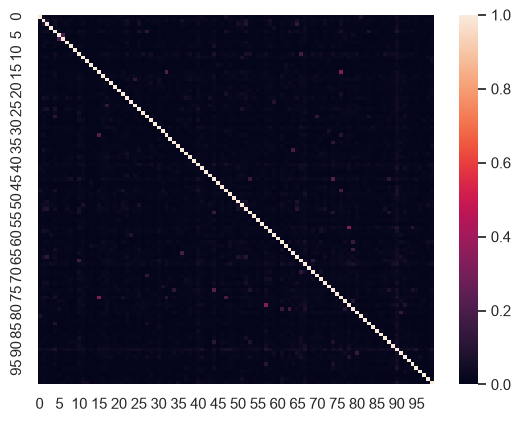

In [28]:
sns.heatmap(cossim_matrix[:100, :100])

In [29]:
# generate serie with the index of each movie
indices = pd.Series(titles.index, index=titles['title'].apply(lambda x: x.lower())) #.drop_duplicates()

In [30]:
indices[:10]

title
the house of the devil        0
beauty and the beast          1
cinderella                    2
a trip to the moon            3
the land beyond the sunset    4
antony and cleopatra          5
julius caesar                 6
a midsummer night's dream     7
frankenstein                  8
the fugitive                  9
dtype: int64

In [31]:
def get_reco(title, cosine_sim=cossim_matrix):
    # Get the index of the movie that matches the title
    title = title.lower()
    idx = indices[title]

    # Get the pairwsie similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # Get the scores of the 10 most similar movies
    sim_scores = sim_scores[1:11]

    # Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # Return the top 10 most similar movies
    return titles[['title', "genres"]].iloc[movie_indices]

In [36]:
np.save("./Transformed_Data/cosine_mat_CBRS.npy",cossim_matrix)
titles.to_csv("./Transformed_Data/movie_description.csv", index=False)

#### 3.2 Examples of recommandation

In [32]:
# recommandation for the first movie
print("first movie title: "+titles['title'].iloc[0] )
print("first movie genres: "+titles['genres'].iloc[0] )
get_reco(titles['title'].iloc[0])

first movie title: The House of the Devil
first movie genres: Horror Short


,title,genres
2208,The Haunted Castle,Comedy Fantasy Musical
322,The Ghost Rider,Drama Western
1614,Sea Devils,Action Adventure Drama
4761,The Black Cauldron,Action Adventure Animation
3834,Spectre,Horror
590,The Devil Bat,Horror Sci-Fi
127,The Bat Whispers,Crime Drama Horror
769,The Devil's Envoys,Drama Fantasy Romance
2082,The Bat,Horror Mystery Thriller
1534,Singin' in the Rain,Comedy Musical Romance


In [33]:
movie_index = 2
def print_reco(movie_index = 0):
    print("first movie title: "+titles['title'].iloc[movie_index] )
    print("first movie genres: "+titles['genres'].iloc[movie_index] )
    print(get_reco(titles['title'].iloc[movie_index]))

print_reco(2)

first movie title: Cinderella
first movie genres: Drama Family Fantasy
                                                  title                      genres
3733  The Slipper and the Rose: The Story of Cinderella    Adventure Family Fantasy
2379                                        The Leopard               Drama History
1960                        The Prince and the Showgirl              Comedy Romance
69                                  The Thief of Bagdad    Adventure Family Fantasy
1743                                  The Glass Slipper      Family Fantasy Musical
985                              Swing Shift Cinderella  Adventure Animation Comedy
2277                   Snow White and the Three Stooges     Adventure Comedy Family
3388                                 The Little Mermaid   Adventure Animation Drama
442                           The Prince and the Pauper      Adventure Drama Family
55                                           Robin Hood    Adventure Family Romance
